# Checkpoint Validation Analysis

This notebook tests the `CheckpointValidator` on a series of checkpoints from a training run.

In [8]:
%load_ext autoreload
%autoreload 2

In [7]:
import os
import torch as t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# !pip install seaborn
import seaborn as sns
from pathlib import Path
import yaml
from tqdm import tqdm

from checkpoint_validator import CheckpointValidator
from hmm import Mess3Proc
from model import HookedTransformerModel

## Setup: Load Configuration and Initialize HMM

In [13]:
# Path to the training run
run_dir = Path("records/20251207_232030")
checkpoint_dir = run_dir / "checkpoints"

# Load config
with open(run_dir / "config.yaml", 'r') as f:
    config = yaml.safe_load(f)

print("Model config:")
print(yaml.dump(config['model'], default_flow_style=False))
print("\nTraining config:")
print(yaml.dump(config['train'], default_flow_style=False))

Model config:
activation_function: relu
d_head: 8
n_ctx: 10
n_embd: 64
n_head: 1
n_inner: 256
n_layer: 4
n_positions: 10
name: HookedTransformerModel
vocab_size: 3


Training config:
batch_size: 64
device: cuda
learning_rate: 2.0e-05
num_epochs: 500000
process: mess3
wandb_project_name: hidden-markov-model
wandb_run_name: reproduction



In [10]:
# Initialize HMM process
hmm_process = Mess3Proc()
print(f"HMM initialized: {hmm_process}")

HMM initialized: <hmm.Mess3Proc object at 0x7f3394e936a0>


## Initialize CheckpointValidator

This creates a cached test dataset (1000 sequences by default) that will be reused across all checkpoints.

In [4]:
# Initialize validator with cached test data
# Note: seq_length must be > n_ctx for LLR validation to work
# Using 100 tokens (much longer than n_ctx=10) for proper LLR computation
validator = CheckpointValidator(
    hmm_process=hmm_process,
    test_size=100,
    seq_length=100,  # Must be > n_ctx for LLR validation
    device='auto',  # Will use cuda if available
    seed=42
)

CheckpointValidator: Using device cpu
Generating test dataset (100 sequences)...
Test dataset cached: torch.Size([100, 100])
Belief states shape: torch.Size([100, 100, 3])


## Find All Checkpoints

In [5]:
# Get all checkpoint files
checkpoint_files = sorted(checkpoint_dir.glob("checkpoint_step_*.pt"))

# Extract step numbers
checkpoint_steps = [int(f.stem.split('_')[-1]) for f in checkpoint_files]

print(f"Found {len(checkpoint_files)} checkpoints")
print(f"Steps: {checkpoint_steps[:5]} ... {checkpoint_steps[-5:]}")

Found 49 checkpoints
Steps: [10000, 100000, 110000, 120000, 130000] ... [50000, 60000, 70000, 80000, 90000]


## Validate All Checkpoints

This will iterate through all checkpoints and compute validation metrics.

In [ ]:
# Store results
results = []

# Path to config file for model initialization
config_path = run_dir / "config.yaml"

# Validate each checkpoint
for checkpoint_file, step in tqdm(zip(checkpoint_files, checkpoint_steps), total=len(checkpoint_files)):
    # Load model (HookedTransformerModel expects config file path)
    model = HookedTransformerModel(str(config_path))
    checkpoint = t.load(checkpoint_file, map_location=validator.device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(validator.device)
    model.eval()
    
    # Run validation (both geometry and LLR)
    metrics = validator.validate_all(
        model=model,
        step=step,
        num_geometry_samples=1000,
        num_llr_samples=1000
    )
    
    # Store results
    result = {'step': step, **metrics}
    results.append(result)
    
    # Clean up
    del model
    del checkpoint
    t.cuda.empty_cache() if t.cuda.is_available() else None

print("\nValidation complete!")

## Convert Results to DataFrame

In [12]:
# Extract per-layer metrics separately
df_data = []
for result in results:
    row = {
        'step': result['step'],
        'mean_r2': result['mean_r2'],
        'best_layer_r2': result['best_layer_r2'],
        'best_layer_idx': result['best_layer_idx'],
        'llr_mean': result['llr_mean'],
        'llr_std': result['llr_std'],
        'llr_min': result['llr_min'],
        'llr_max': result['llr_max'],
        'true_ll_mean': result['true_ll_mean'],
        'model_ll_mean': result['model_ll_mean']
    }
    df_data.append(row)

df = pd.DataFrame(df_data).sort_values(by="step", ascending=True).reset_index(drop=True)
print(df.head())
print(f"\nDataFrame shape: {df.shape}")

    step   mean_r2  best_layer_r2  best_layer_idx  llr_mean   llr_std  \
0  10000  0.998479       0.998904               3  0.167732  0.640486   
1  20000  0.999437       0.999616               1  0.152845  0.481854   
2  30000  0.999664       0.999797               2  0.129843  0.406617   
3  40000  0.999724       0.999799               2  0.297381  0.532916   
4  50000  0.999702       0.999814               2  0.146291  0.381934   

    llr_min   llr_max  true_ll_mean  model_ll_mean  
0 -1.207571  1.751323    -71.521169     -71.688904  
1 -0.860590  1.220871    -71.521169     -71.674011  
2 -0.885929  1.039164    -71.521169     -71.651009  
3 -0.931293  1.556896    -71.521169     -71.818550  
4 -0.856084  1.198744    -71.521169     -71.667458  

DataFrame shape: (49, 10)


## Save Results

In [13]:
# Save to parquet
output_file = run_dir / "checkpoint_validation_results.parquet"
df.to_parquet(output_file)
print(f"Saved results to {output_file}")

Saved results to records/20251207_232030/checkpoint_validation_results.parquet


## Visualization: Training Curves

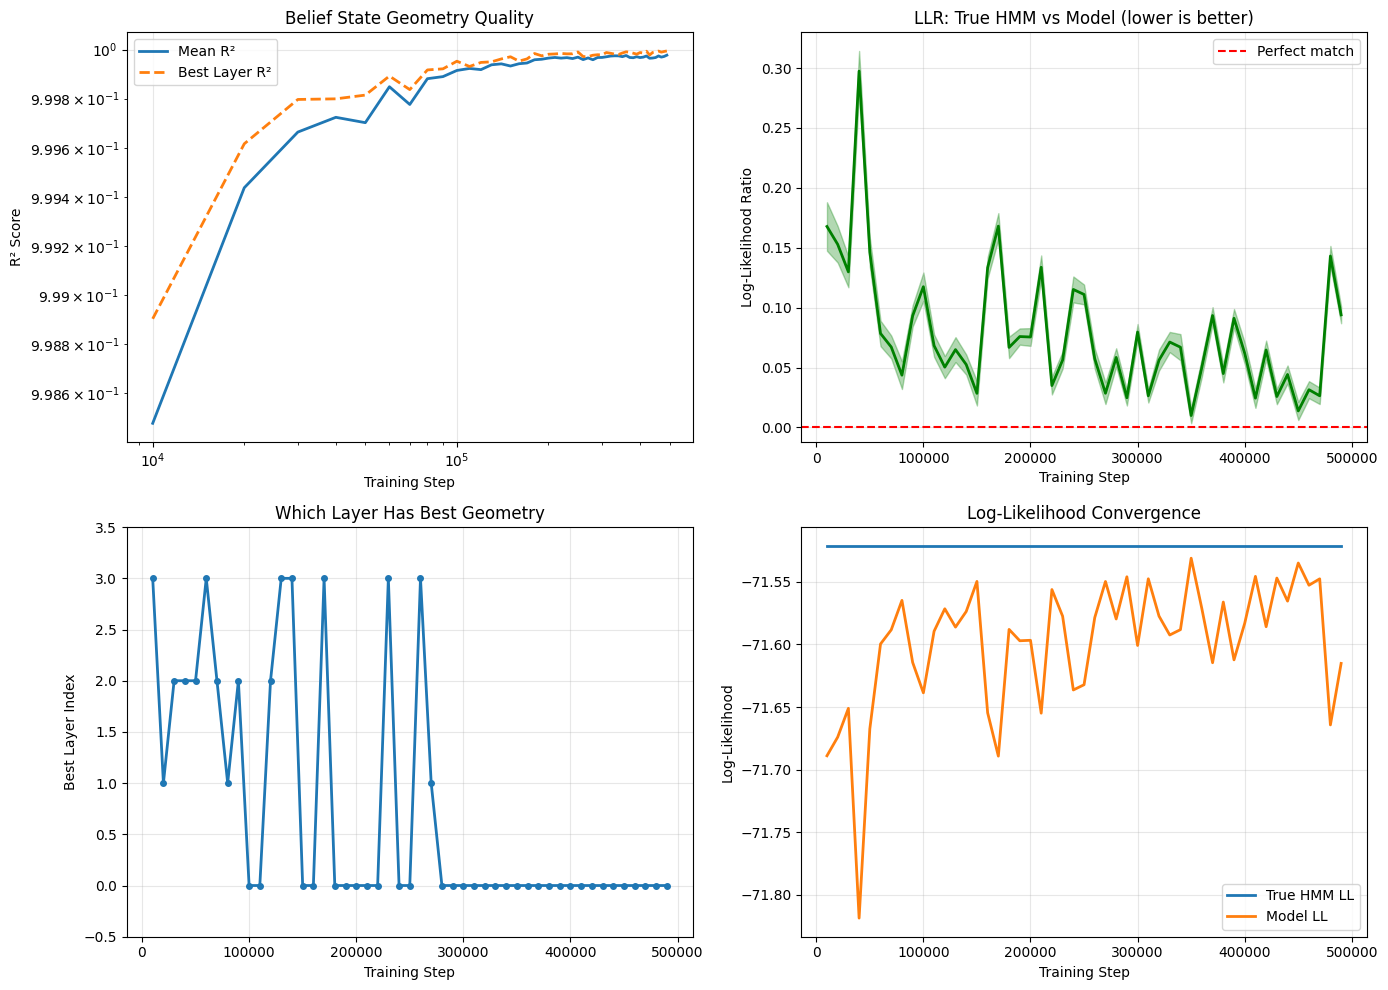

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Geometry R² over training
ax = axes[0, 0]
ax.plot(df['step'], df['mean_r2'], label='Mean R²', linewidth=2)
ax.plot(df['step'], df['best_layer_r2'], label='Best Layer R²', linewidth=2, linestyle='--')
ax.set_xlabel('Training Step')
ax.set_ylabel('R² Score')
ax.set_title('Belief State Geometry Quality')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Log-Likelihood Ratio
ax = axes[0, 1]
ax.plot(df['step'], df['llr_mean'], linewidth=2, color='green')
ax.fill_between(df['step'], 
                 df['llr_mean'] - df['llr_std'] / np.sqrt(1000),
                 df['llr_mean'] + df['llr_std'] / np.sqrt(1000), 
                 alpha=0.3, color='green')
ax.axhline(y=0, color='red', linestyle='--', label='Perfect match')
ax.set_xlabel('Training Step')
ax.set_ylabel('Log-Likelihood Ratio')
ax.set_title('LLR: True HMM vs Model (lower is better)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Best Layer Index Evolution
ax = axes[1, 0]
ax.plot(df['step'], df['best_layer_idx'], linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Training Step')
ax.set_ylabel('Best Layer Index')
ax.set_title('Which Layer Has Best Geometry')
ax.set_ylim(-0.5, config['model']['n_layer'] - 0.5)
ax.grid(True, alpha=0.3)

# Plot 4: Model vs True Log-Likelihood
ax = axes[1, 1]
ax.plot(df['step'], df['true_ll_mean'], label='True HMM LL', linewidth=2)
ax.plot(df['step'], df['model_ll_mean'], label='Model LL', linewidth=2)
ax.set_xlabel('Training Step')
ax.set_ylabel('Log-Likelihood')
ax.set_title('Log-Likelihood Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(run_dir / 'checkpoint_validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Per-Layer R² Heatmap

In [ ]:
# Extract per-layer R² scores
n_layers = config['model']['n_layer']
r2_matrix = np.zeros((len(results), n_layers))

for i, result in enumerate(results):
    r2_matrix[i, :] = result['r2_scores']

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(r2_matrix.T, aspect='auto', cmap='viridis', origin='lower')

# Set labels
ax.set_xlabel('Checkpoint Index')
ax.set_ylabel('Layer Index')
ax.set_title('R² Score Evolution Across Layers')

# Set x-tick labels to show actual steps
tick_indices = np.linspace(0, len(checkpoint_steps)-1, min(10, len(checkpoint_steps)), dtype=int)
ax.set_xticks(tick_indices)
ax.set_xticklabels([checkpoint_steps[i] for i in tick_indices], rotation=45)

# Colorbar
plt.colorbar(im, ax=ax, label='R² Score')

plt.tight_layout()
plt.savefig(run_dir / 'checkpoint_validation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary Statistics

In [ ]:
print("=" * 60)
print("CHECKPOINT VALIDATION SUMMARY")
print("=" * 60)
print(f"\nTotal checkpoints validated: {len(df)}")
print(f"Training steps range: {df['step'].min()} - {df['step'].max()}")

print("\n--- Final Checkpoint ---")
final = df.iloc[-1]
print(f"Step: {final['step']}")
print(f"Mean R²: {final['mean_r2']:.4f}")
print(f"Best Layer R²: {final['best_layer_r2']:.4f} (Layer {final['best_layer_idx']})")
print(f"LLR Mean: {final['llr_mean']:.4f} ± {final['llr_std']:.4f}")

print("\n--- Best Performing Checkpoint ---")
best_idx = df['best_layer_r2'].idxmax()
best = df.iloc[best_idx]
print(f"Step: {best['step']}")
print(f"Mean R²: {best['mean_r2']:.4f}")
print(f"Best Layer R²: {best['best_layer_r2']:.4f} (Layer {best['best_layer_idx']})")
print(f"LLR Mean: {best['llr_mean']:.4f} ± {best['llr_std']:.4f}")

print("\n--- Statistics Summary ---")
print(df[['mean_r2', 'best_layer_r2', 'llr_mean', 'llr_std']].describe())

## New sweeps

In [4]:
import pandas as pd
metadata_path = 'records/metadata.parquet'

df = pd.read_parquet(metadata_path)
df_completed = df[df['status'] == 'completed']
df_completed.keys()
len(df_completed)

16

In [5]:
df_completed.sort_values(by=['final_val_loss', 'param_count'], ascending=True).loc[:, ['final_val_loss', 'param_count', 'n_ctx']].head(10)
# example_model = df_completed.iloc[732]['param_count']


,final_val_loss,param_count,n_ctx
5,0.800427,198464.0,10.0
90,0.805094,360.0,10.0
88,0.808100,116.0,10.0
89,0.809762,344.0,8.0
67,0.817608,100.0,6.0
1,0.817919,616.0,10.0
2,0.820620,656.0,15.0
77,0.820958,312.0,4.0
3,0.821974,584.0,6.0
4,0.822044,600.0,8.0


In [12]:
# example_model
model_dir = df.iloc[90]['run_dir']
# model_dir = 'records/20251209_100906_6c779fde'
print(model_dir)

# load the model
model = HookedTransformerModel(os.path.join(model_dir, "config.yaml"))
model.load_state_dict(t.load(os.path.join(model_dir, 'final_model_mess3.pt'), map_location='cpu'))

# validate the model
validator = CheckpointValidator(
    hmm_process=hmm_process,
    test_size=100,
    seq_length=100,  # Must be > n_ctx for LLR validation to work
    device='cpu',
    seed=42
)

# validate the model
metrics = validator.validate_all(
    model=model,
    step=-1,
    num_geometry_samples=1000,
    num_llr_samples=1000
)

# print the metrics
print(metrics)


/mnt/users/clin/workspace/hidden-markov-chain/records/20251209_112554_de162854
CheckpointValidator: Using device cpu
Generating test dataset (100 sequences)...
Test dataset cached: torch.Size([100, 100])
Belief states shape: torch.Size([100, 100, 3])

Checkpoint Validation at Step -1
Truncating sequences from 100 to 10 (model's n_ctx)
Running geometry validation on 100 samples...
Moving model to device:  cpu
Shape of [belief_states]: torch.Size([100, 3])
Shape of [actvs]: torch.Size([100, 8])
Layer 0 - MSE: 0.001993, R²: 0.987006, Baseline MSE: 0.152518
Using default offset = 9 (n_ctx - 1)
Running LLR validation on 100 samples...
{'r2_scores': [0.9870061874389648], 'mses': [np.float32(0.001993315)], 'baseline_mses': [np.float32(0.15251832)], 'mean_r2': 0.9870061874389648, 'best_layer_r2': 0.9870061874389648, 'best_layer_idx': 0, 'llr_mean': 0.4574840417826458, 'llr_std': 0.8062305239291425, 'llr_min': -1.8436830262625108, 'llr_max': 2.444620913371665, 'true_ll_mean': -71.47535676327108

In [ ]:
from pca import plot_in_simplex
